# Comparison of different capabilities of recognizing language in models

**Authors:** Hannah Buch, Yassine Ajoud

This notebook compares how a language model can identify literary text by evaluating:
- English books from Project Gutenberg
- German translations mapped to their English originals
## Sections

1. Setup
2. English books
3. German translations of English books
4. German books with German titles
5. French books with French titles
6. Italian books with Italian titles
7. Dutch books with Dutch titles

## 1. Setup

Imports and global settings.

In [1]:
import os
import random
import re
import csv
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt


In [2]:

# Global settings
NUM_TARGET_BOOKS = 100
SNIPPET_LENGTH = 1000
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

## 2. English books

This part loads English books from the Gutenberg dataset, creates short text snippets, and builds a multiple-choice task where the correct answer is the book title.

In [3]:
def parse_metadata(text):
    """
    Extract the title from a Gutenberg text header.
    Returns a string with the title or 'Unknown Title'.
    """
    title = "Unknown Title"

    title_match = re.search(
        r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)",
        text,
        re.IGNORECASE | re.DOTALL,
    )
    if title_match:
        raw_title = title_match.group(1)
        title = re.sub(r"\s+", " ", raw_title).strip()

    return title


def is_a_translation(text):
    """
    Check whether the Gutenberg text looks like a translation.
    """
    translator_match = re.search(r"Translator:\s*(.*)", text, re.IGNORECASE)
    return translator_match is not None


def load_books_from_stream(dataset, parse_title_fn, target_count, snippet_length=1000, skip_fn=None):
    """
    Load books from a streaming dataset and create a short text excerpt for each.
    """
    books = []
    seen_titles = set()
    iterator = iter(dataset)

    while len(books) < target_count:
        try:
            item = next(iterator)
            text = item["text"]

            title = parse_title_fn(text)

            if title == "Unknown Title":
                continue

            if skip_fn and skip_fn(text):
                continue

            snippet_start = len(text) // 2
            snippet_end = snippet_start + snippet_length
            snippet = text[snippet_start:snippet_end].strip()

            title_lower = title.lower()
            if title_lower in seen_titles:
                continue

            seen_titles.add(title_lower)
            books.append({
                "title": title,
                "text": snippet
            })

        except StopIteration:
            print("Reached end of dataset before target count was reached.")
            break

    return books

In [4]:
print("Loading English Gutenberg books...")
dataset_en = load_dataset("manu/project_gutenberg", split="en", streaming=True)

english_books = load_books_from_stream(
    dataset_en,
    parse_title_fn=parse_metadata,
    target_count=NUM_TARGET_BOOKS,
    snippet_length=SNIPPET_LENGTH,
    skip_fn=is_a_translation,
)

print(f"Loaded {len(english_books)} English books.")

Loading English Gutenberg books...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 English books.


### 2.1 Create English multiple-choice questions

Each English book becomes a question. The correct answer is the book title, and the three wrong answers are sampled from the other titles.

In [5]:
def build_multiple_choice_questions(books, correct_title_key, text_key):
    """
    Create a multiple-choice evaluation set from a list of books.
    """
    evaluation_set = []
    all_titles = [book[correct_title_key] for book in books]

    for book in books:
        correct_title = book[correct_title_key]

        wrong_choices = [t for t in all_titles if t != correct_title]

        if len(wrong_choices) < 3:
            raise ValueError("Not enough titles to create distractors.")

        choices = random.sample(wrong_choices, 3) + [correct_title]
        random.shuffle(choices)

        correct_letter = chr(65 + choices.index(correct_title))

        evaluation_set.append({
            "snippet": book[text_key],
            "choices": choices,
            "correct_letter": correct_letter,
            "correct_title": correct_title,
        })

    return evaluation_set

In [6]:
english_evaluation_set = build_multiple_choice_questions(
    english_books,
    correct_title_key="title",
    text_key="text",
)

print(f"Created {len(english_evaluation_set)} English multiple-choice questions.")

Created 100 English multiple-choice questions.


### 2.2 Evaluate the model on English questions

Now the Qwen model is asked to choose the correct book title for each English snippet.

In [7]:
print(f"Loading model: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)

correct_predictions = 0
failed_parses = 0

for i, item in enumerate(english_evaluation_set):
    prompt_choices = "\n".join([
        f"{chr(65 + idx)}) {choice}"
        for idx, choice in enumerate(item["choices"])
    ])

    system_prompt = (
        "Your task is to identify which book a provided text snippet belongs to. "
        "Respond ONLY with the single letter choice (A, B, C, or D) corresponding to the correct book title. "
        "Do not output anything else."
    )

    user_prompt = (
        f"\n\"\"\"\n{item['snippet']}\n\"\"\"\n\n"
        f"Which book is this snippet from?\n{prompt_choices}\n\n"
        f"Answer (A/B/C/D):"
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=4,
            temperature=0.1,
            do_sample=False,
        )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses += 1

    if predicted_letter == item["correct_letter"]:
        correct_predictions += 1

    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions / (i + 1)) * 100
        print(f"Evaluated {i+1}/{len(english_evaluation_set)} | Running Accuracy: {current_acc:.1f}%")

Loading model: Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Evaluated 10/100 | Running Accuracy: 80.0%
Evaluated 20/100 | Running Accuracy: 80.0%
Evaluated 30/100 | Running Accuracy: 83.3%
Evaluated 40/100 | Running Accuracy: 85.0%
Evaluated 50/100 | Running Accuracy: 84.0%
Evaluated 60/100 | Running Accuracy: 85.0%
Evaluated 70/100 | Running Accuracy: 84.3%
Evaluated 80/100 | Running Accuracy: 83.8%
Evaluated 90/100 | Running Accuracy: 84.4%
Evaluated 100/100 | Running Accuracy: 85.0%


### 2.3 Show English results

This final step visualizes how many questions were answered correctly, incorrectly, or failed to parse.

In [10]:
def plot_results(correct_predictions, failed_parses, evaluation_set, title):
    """
    Plot a pie chart of correct, incorrect, and failed-parsed answers.
    """
    total_questions = len(evaluation_set)
    incorrect_predictions = total_questions - correct_predictions - failed_parses

    labels = ["Correct", "Incorrect", "Errors"]
    sizes = [correct_predictions, incorrect_predictions, failed_parses]
    colors = ["#4CAF50", "#E3311D", "#FF9800"]

    plt.figure(figsize=(8, 6))
    plt.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct=lambda p: f"{p:.1f}%\n({p * total_questions / 100:.0f} books)" if p > 0 else "",
        shadow=True,
        startangle=140,
        textprops={"fontsize": 12},
    )

    accuracy = (correct_predictions / total_questions) * 100
    plt.title(
        f"{title}\nOverall Accuracy: {accuracy:.2f}% (Total: {total_questions} Books)",
        fontsize=14,
        fontweight="bold",
    )

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

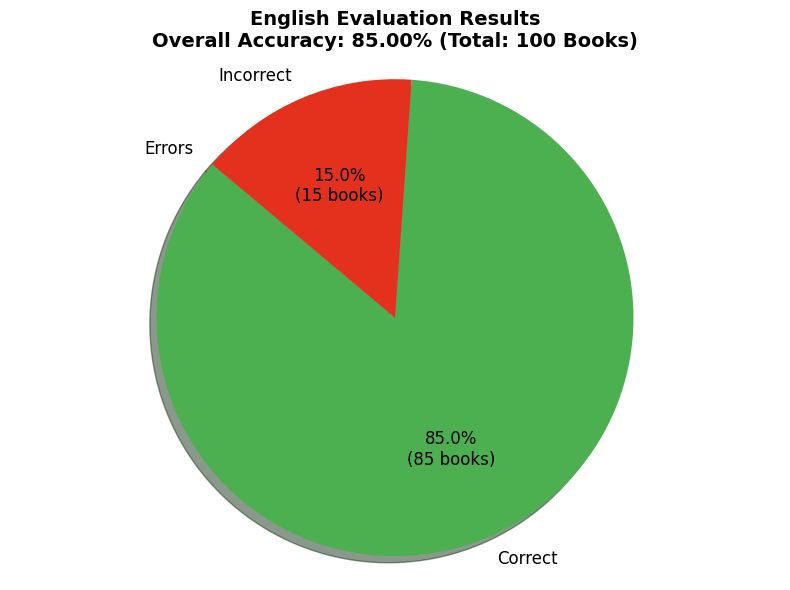

In [11]:
plot_results(
    correct_predictions=correct_predictions,
    failed_parses=failed_parses,
    evaluation_set=english_evaluation_set,
    title="English Evaluation Results",
)

## 3. German translations and evaluation

This section uses the manually mapped Gutenberg IDs from the CSV to:
- load German Gutenberg books,
- create a short text snippet for each book,
- build a multiple-choice task where the correct answer is the English original title,
- and evaluate the model on this task.

In [12]:
def parse_metadata_and_id(text):
    """
    Extract Gutenberg ID, title, and author from a German Gutenberg header.
    """
    title = "Unknown Title"
    author = "Unknown Author"
    gutenberg_id = "Unknown ID"

    id_match = re.search(r"\[eBook\s*#?(\d+)\]", text, re.IGNORECASE)
    if id_match:
        gutenberg_id = id_match.group(1)

    title_match = re.search(
        r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)",
        text,
        re.IGNORECASE | re.DOTALL,
    )
    if title_match:
        raw_title = title_match.group(1)
        title = re.sub(r"\s+", " ", raw_title).strip()

    author_match = re.search(
        r"Author:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)",
        text,
        re.IGNORECASE | re.DOTALL,
    )
    if author_match:
        raw_author = author_match.group(1)
        author = re.sub(r"\s+", " ", raw_author).strip()

    return gutenberg_id, title, author


def is_translation_from_english(text, author=""):
    """
    Detect whether a German Gutenberg text looks like a translation from English.
    """
    header_area = text[:4000].lower()

    german_translation_patterns = [
        r"aus\s+dem\s+englischen",
        r"aus\s+d\.\s+englischen",
        r"übersetzung\s+aus\s+dem\s+englischen",
        r"uebersetzung\s+aus\s+dem\s+englischen",
        r"übersetzt\s+aus\s+dem\s+englischen",
        r"uebersetzt\s+aus\s+dem\s+englischen",
        r"übertragen\s+aus\s+dem\s+englischen",
        r"uebertragen\s+aus\s+dem\s+englischen",
        r"vom\s+englischen\s+ins\s+deutsche",
        r"deutsch\s+von.*englischen",
    ]

    for pattern in german_translation_patterns:
        if re.search(pattern, header_area):
            return True, "Recognized via phrase: 'aus dem Englischen'"

    has_translator = "translator:" in header_area or "übersetzer:" in header_area or "uebersetzer:" in header_area

    if has_translator and author:
        famous_english_authors = {
            "shakespeare", "dickens", "twain", "poe", "conan doyle", "wilde", "london", "kipling",
            "wells", "austen", "bront", "shelley", "stoker", "carroll", "melville", "hawthorne",
            "swift", "defoe", "hardy", "thackeray", "alcott", "cooper", "irving", "emerson", "whitman"
        }

        author_clean = author.lower()
        for eng_author in famous_english_authors:
            if eng_author in author_clean:
                return True, f"English author ({author}) with translator metadata."

    return False, ""


def create_translation_csv(output_filename="Gutenberg_Uebersetzungen_Liste.csv"):
    """
    Scan the German Gutenberg dataset, detect likely English-to-German translations,
    and write them to a CSV file.
    """
    print("Scanning German Gutenberg books to create translation CSV...")
    dataset_de = load_dataset("manu/project_gutenberg", split="de")

    translations = []
    seen_ids = set()

    for item in dataset_de:
        text = item["text"]
        gutenberg_id, title, author = parse_metadata_and_id(text)
        matched, reason = is_translation_from_english(text, author)

        if matched and gutenberg_id != "Unknown ID" and gutenberg_id not in seen_ids:
            seen_ids.add(gutenberg_id)
            translations.append({
                "Gutenberg ID": gutenberg_id,
                "Deutscher Titel": title,
                "Autor": author,
                "Erkennungsgrund": reason,
                "Originaler Englischer Titel (Manuell)": ""
            })

    with open(output_filename, mode="w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["Gutenberg ID", "Deutscher Titel", "Autor", "Erkennungsgrund", "Originaler Englischer Titel (Manuell)"],
            delimiter=";"
        )
        writer.writeheader()
        for row in translations:
            writer.writerow(row)

    print(f"Created {len(translations)} translation entries in {output_filename}.")
    return output_filename

In [13]:
csv_path = "Gutenberg_Uebersetzungen_Liste.csv"

if os.path.exists(csv_path):
    print(f"Using existing CSV: {csv_path}")
else:
    csv_path = create_translation_csv(csv_path)

Using existing CSV: Gutenberg_Uebersetzungen_Liste.csv


### 3.1 Load the mapping table

This step reads the CSV file that contains the manually matched Gutenberg IDs, German titles, and English titles.

In [14]:
def load_manually_mapped_books_csv(csv_path):
    """
    Load the manually mapped Gutenberg IDs and their German/English titles.
    The CSV uses ';' as delimiter.
    """
    print(f"Loading manual mappings from {csv_path}...")
    title_lookup = {}

    try:
        with open(csv_path, mode="r", encoding="utf-8-sig") as f:
            reader = csv.DictReader(f, delimiter=";")
            for row in reader:
                book_id = row["Gutenberg ID"].strip()
                german_title = row["Deutscher Titel"].strip()
                english_title = row["Originaler Englischer Titel"].strip()

                title_lookup[book_id] = {
                    "english_title": english_title,
                    "german_title": german_title,
                }
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")

    return title_lookup

In [15]:
title_lookup = load_manually_mapped_books_csv(csv_path)

all_english_titles = [
    entry["english_title"]
    for entry in title_lookup.values()
    if entry.get("english_title", "").strip()
]

print(f"Loaded {len(title_lookup)} title mappings.")
print(f"Found {len(all_english_titles)} English titles for distractors.")

Loading manual mappings from Gutenberg_Uebersetzungen_Liste.csv...
Loaded 23 title mappings.
Found 23 English titles for distractors.


### 3.2 Load German books and create snippets

The German Gutenberg dataset is streamed book by book.  
For each book, we extract the Gutenberg ID and title information, match it to the CSV entry, and create a short text snippet.

In [16]:
print("Loading German Gutenberg books...")
dataset_de = load_dataset("manu/project_gutenberg", split="de", streaming=True)

german_books = []
seen_ids = set()
iterator = iter(dataset_de)

while len(german_books) < len(title_lookup):
    try:
        item = next(iterator)
        text = item["text"]

        gutenberg_id, german_title, author = parse_metadata_and_id(text)

        if gutenberg_id == "Unknown ID":
            continue

        mapping = title_lookup.get(gutenberg_id)
        if not mapping:
            continue

        english_title = mapping["english_title"]
        german_title = mapping["german_title"]

        if gutenberg_id in seen_ids:
            continue
        seen_ids.add(gutenberg_id)

        snippet = text[1000:4000].strip()

        german_books.append({
            "german_title": german_title,
            "english_title": english_title,
            "text_snippet": snippet,
        })

        print(f"Loaded {len(german_books)} German books. Matched: '{german_title}' -> '{english_title}'")

    except StopIteration:
        print("Dataset stream finished. Not all German books listed in the CSV could be loaded.")
        break

print(f"Dataset preparation done. Loaded total of {len(german_books)} books.")

Loading German Gutenberg books...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 1 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Siebenter Band: enthaltend Kapitel 13 und 14.' -> 'The History of England from the Accession of James II'
Loaded 2 German books. Matched: 'Das Bildnis des Dorian Gray' -> 'The Picture of Dorian Gray'
Loaded 3 German books. Matched: 'Zwei Städte' -> 'A Tale of Two Cities'
Loaded 4 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Dritter Band' -> 'The History of England from the Accession of James II'
Loaded 5 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Erster Band enthaltend Kapitel 1 und 2' -> 'The History of England from the Accession of James II'
Loaded 6 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Zweiter Band' -> 'The History of England from the Accession of James II'
Loaded 7 German books. Matched: 'Geschichte von England seit der Thronbeste

### 3.3 Build the German multiple-choice evaluation set

Each German book becomes one question.  
The correct answer is the English original title of the book, while the three wrong answers are sampled from the larger pool of English titles.

In [17]:
german_evaluation_set = []

for book in german_books:
    correct_title = book["english_title"].strip()

    wrong_choices = [t for t in all_english_titles if t != correct_title]

    if len(wrong_choices) < 3:
        continue

    choices = random.sample(wrong_choices, 3) + [correct_title]
    random.shuffle(choices)

    correct_idx = choices.index(correct_title)
    correct_letter = chr(65 + correct_idx)

    german_evaluation_set.append({
        "snippet": book["text_snippet"],
        "choices": choices,
        "correct_letter": correct_letter,
        "correct_title": correct_title,
        "german_title": book["german_title"],
    })

print(f"Created {len(german_evaluation_set)} German multiple-choice questions.")

Created 23 German multiple-choice questions.


### 3.4 Run the model on the German questions

This cell loads the language model and asks it to identify the correct English original title for each German book snippet.

In [18]:
print(f"Loading model: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)

correct_predictions_de = 0
failed_parses_de = 0

for i, item in enumerate(german_evaluation_set):
    prompt_choices = "\n".join([
        f"{chr(65 + idx)}) {choice}"
        for idx, choice in enumerate(item["choices"])
    ])

    system_prompt = (
        "You are a helpful assistant. Read the German book text and identify the English original title."
    )

    user_prompt = (
        f"Here is the beginning of a German book:\n\n{item['snippet']}\n\n"
        f"Which is the English original title of this book? Choose the correct option:\n"
        f"{prompt_choices}\n\n"
        f"Answer ONLY with the corresponding capital letter (A, B, C, or D)."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
        )

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses_de += 1

    if predicted_letter == item["correct_letter"]:
        correct_predictions_de += 1

    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions_de / (i + 1)) * 100
        print(f"Evaluated {i+1}/{len(german_evaluation_set)} | Running Accuracy: {current_acc:.1f}%")

Loading model: Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


Evaluated 10/23 | Running Accuracy: 10.0%
Evaluated 20/23 | Running Accuracy: 30.0%


### 3.5 Show German results

This final step visualizes how many German questions were answered correctly, incorrectly, or failed to parse.

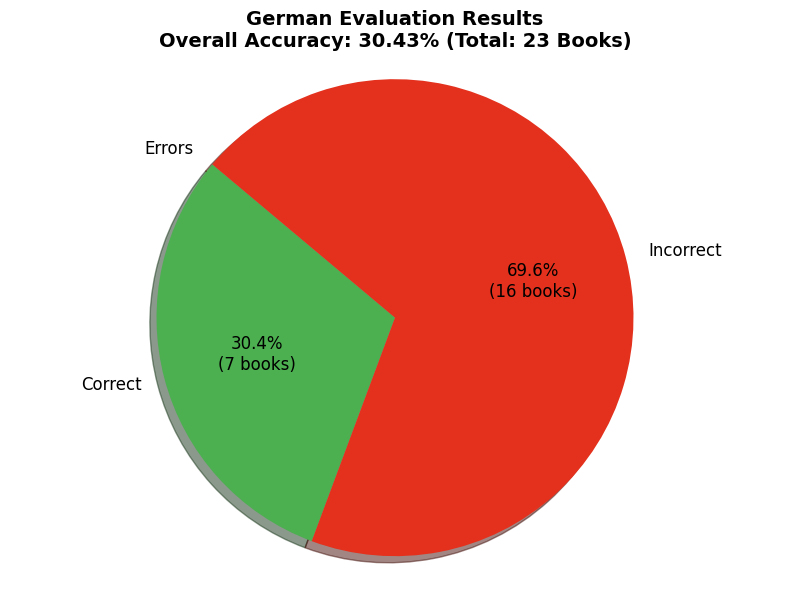

In [19]:
plot_results(
    correct_predictions=correct_predictions_de,
    failed_parses=failed_parses_de,
    evaluation_set=german_evaluation_set,
    title="German Evaluation Results",
)

## 4. German books with German titles

This section loads German Gutenberg books that are not detected as translations from English, creates short text snippets, and builds a multiple-choice task using German titles.

In [20]:
def load_german_non_translation_books(dataset, target_count=100, snippet_length=1000):
    """
    Load German Gutenberg books that are not detected as translations from English.
    Each returned item contains a German title and a short text snippet.
    """
    books = []
    seen_titles = set()
    iterator = iter(dataset)

    while len(books) < target_count:
        try:
            item = next(iterator)
            text = item["text"]

            gutenberg_id, german_title, author = parse_metadata_and_id(text)

            if gutenberg_id == "Unknown ID":
                continue

            is_translation, _ = is_translation_from_english(text, author)
            if is_translation:
                continue

            if german_title == "Unknown Title":
                continue

            title_lower = german_title.lower()
            if title_lower in seen_titles:
                continue
            seen_titles.add(title_lower)

            snippet_start = len(text) // 2
            snippet_end = snippet_start + snippet_length
            snippet = text[snippet_start:snippet_end].strip()

            books.append({
                "german_title": german_title,
                "text": snippet,
            })

        except StopIteration:
            print("Reached end of German dataset before target count was reached.")
            break

    return books

In [21]:
print("Loading German non-translation books...")
dataset_de_non_translation = load_dataset("manu/project_gutenberg", split="de", streaming=True)

german_non_translation_books = load_german_non_translation_books(
    dataset_de_non_translation,
    target_count=100,
    snippet_length=SNIPPET_LENGTH,
)

print(f"Loaded {len(german_non_translation_books)} German non-translation books.")

Loading German non-translation books...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 German non-translation books.


In [22]:
german_title_evaluation_set = build_multiple_choice_questions(
    german_non_translation_books,
    correct_title_key="german_title",
    text_key="text",
)

print(f"Created {len(german_title_evaluation_set)} German-title multiple-choice questions.")

Created 100 German-title multiple-choice questions.


In [23]:
# Load the model only if it has not already been loaded in this session
if "tokenizer" not in globals() or "model" not in globals():
    print(f"Loading model: {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype="auto",
        device_map="auto",
    )

correct_predictions_de_title = 0
failed_parses_de_title = 0

for i, item in enumerate(german_title_evaluation_set):
    prompt_choices = "\n".join([
        f"{chr(65 + idx)}) {choice}"
        for idx, choice in enumerate(item["choices"])
    ])

    system_prompt = (
        "You are a helpful assistant. Read the provided German book text "
        "and determine the correct German book title."
    )

    user_prompt = (
        f"Here is the beginning of a German book:\n\n{item['snippet']}\n\n"
        f"Which German book is this excerpt from? Choose the correct option:\n"
        f"{prompt_choices}\n\n"
        f"Respond ONLY with the corresponding capital letter (A, B, C, or D)."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
        )

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses_de_title += 1

    if predicted_letter == item["correct_letter"]:
        correct_predictions_de_title += 1

    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions_de_title / (i + 1)) * 100
        print(f"Evaluated {i+1}/{len(german_title_evaluation_set)} | Running Accuracy: {current_acc:.1f}%")

Evaluated 10/100 | Running Accuracy: 30.0%
Evaluated 20/100 | Running Accuracy: 30.0%
Evaluated 30/100 | Running Accuracy: 23.3%
Evaluated 40/100 | Running Accuracy: 22.5%
Evaluated 50/100 | Running Accuracy: 24.0%
Evaluated 60/100 | Running Accuracy: 21.7%
Evaluated 70/100 | Running Accuracy: 24.3%
Evaluated 80/100 | Running Accuracy: 25.0%
Evaluated 90/100 | Running Accuracy: 22.2%
Evaluated 100/100 | Running Accuracy: 22.0%


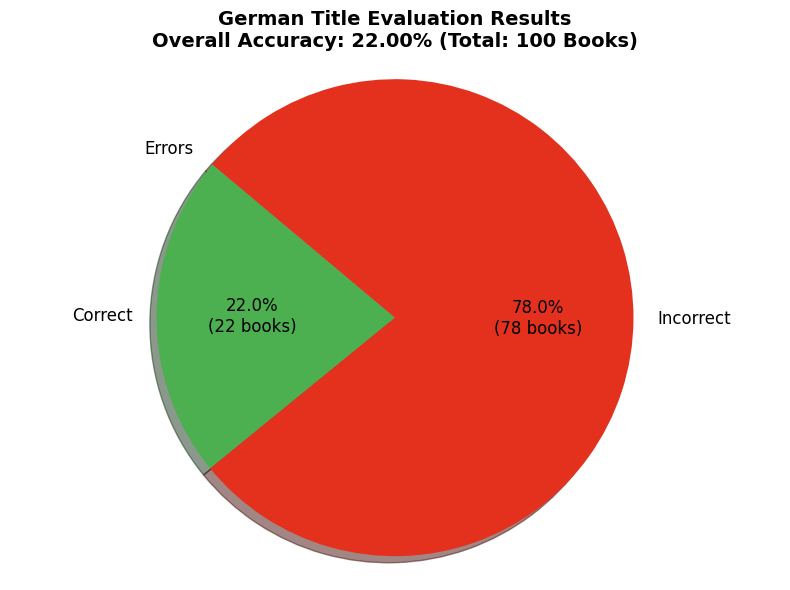

In [24]:
plot_results(
    correct_predictions=correct_predictions_de_title,
    failed_parses=failed_parses_de_title,
    evaluation_set=german_title_evaluation_set,
    title="German Title Evaluation Results",
)

## 5. French books with French titles

This section loads French Gutenberg books, creates short text snippets and builds a multiple-choice test using French titles.

In [25]:
print("Loading French Gutenberg books...")
dataset_fr = load_dataset("manu/project_gutenberg", split="fr", streaming=True)

french_books = load_books_from_stream(
    dataset_fr,
    parse_title_fn=parse_metadata,
    target_count=100,
    snippet_length=SNIPPET_LENGTH,
    skip_fn=None,
)

print(f"Loaded {len(french_books)} French books.")

Loading French Gutenberg books...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 French books.


In [26]:
french_evaluation_set = build_multiple_choice_questions(
    french_books,
    correct_title_key="title",
    text_key="text",
)

print(f"Created {len(french_evaluation_set)} French multiple-choice questions.")

Created 100 French multiple-choice questions.


In [27]:
# Load the model only if it has not already been loaded in this session
if "tokenizer" not in globals() or "model" not in globals():
    print(f"Loading model: {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype="auto",
        device_map="auto",
    )

correct_predictions_fr_title = 0
failed_parses_fr_title = 0

for i, item in enumerate(french_evaluation_set):
    prompt_choices = "\n".join([
        f"{chr(65 + idx)}) {choice}"
        for idx, choice in enumerate(item["choices"])
    ])

    system_prompt = (
        "Tu es un assistant utile. Lis le texte du livre français fourni "
        "et détermine le bon titre français."
    )

    user_prompt = (
        f"Voici le début d'un livre français:\n\n{item['snippet']}\n\n"
        f"De quel livre français provient cet extrait ? Choisis la bonne option:\n"
        f"{prompt_choices}\n\n"
        f"Réponds UNIQUEMENT avec la lettre correspondante (A, B, C ou D)."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
        )

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses_fr_title += 1

    if predicted_letter == item["correct_letter"]:
        correct_predictions_fr_title += 1

    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions_fr_title / (i + 1)) * 100
        print(f"Evaluated {i+1}/{len(french_evaluation_set)} | Running Accuracy: {current_acc:.1f}%")

Evaluated 10/100 | Running Accuracy: 10.0%
Evaluated 20/100 | Running Accuracy: 10.0%
Evaluated 30/100 | Running Accuracy: 13.3%
Evaluated 40/100 | Running Accuracy: 20.0%
Evaluated 50/100 | Running Accuracy: 18.0%
Evaluated 60/100 | Running Accuracy: 16.7%
Evaluated 70/100 | Running Accuracy: 18.6%
Evaluated 80/100 | Running Accuracy: 21.2%
Evaluated 90/100 | Running Accuracy: 21.1%
Evaluated 100/100 | Running Accuracy: 22.0%


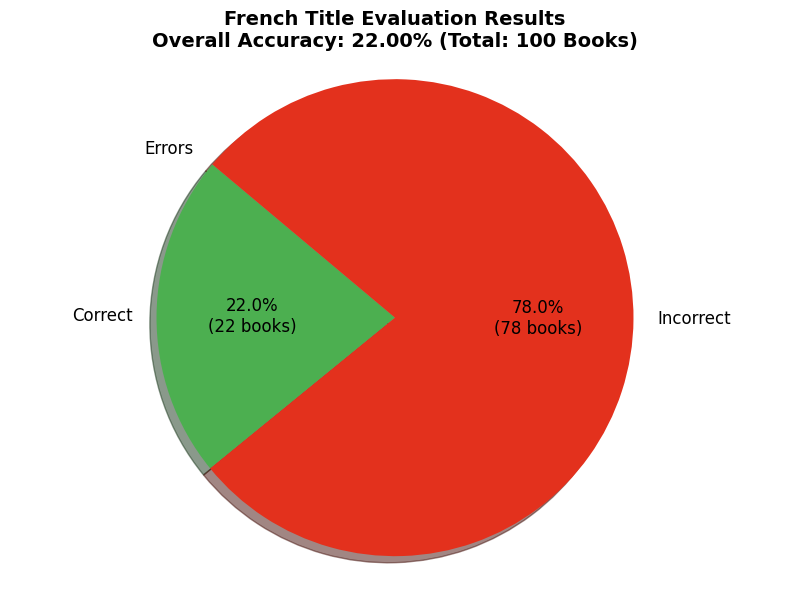

In [28]:
plot_results(
    correct_predictions=correct_predictions_fr_title,
    failed_parses=failed_parses_fr_title,
    evaluation_set=french_evaluation_set,
    title="French Title Evaluation Results",
)

## 6. Italian books with Italian titles

This section loads Italian Gutenberg books, creates short text snippets and builds a multiple-choice test using Italian titles.

In [29]:
print("Loading Italian Gutenberg books...")
dataset_it = load_dataset("manu/project_gutenberg", split="it", streaming=True)

italian_books = load_books_from_stream(
    dataset_it,
    parse_title_fn=parse_metadata,
    target_count=NUM_TARGET_BOOKS,
    snippet_length=SNIPPET_LENGTH,
    skip_fn=None,
)

print(f"Loaded {len(italian_books)} Italian books.")

Loading Italian Gutenberg books...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 Italian books.


In [ ]:
italian_evaluation_set = build_multiple_choice_questions(
    italian_books,
    correct_title_key="title",
    text_key="text",
)

print(f"Created {len(italian_evaluation_set)} Italian multiple-choice questions.")

Created 100 Italian multiple-choice questions.


In [31]:
# Load the model only if it has not already been loaded in this session
if "tokenizer" not in globals() or "model" not in globals():
    print(f"Loading model: {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype="auto",
        device_map="auto",
    )

correct_predictions_it_title = 0
failed_parses_it_title = 0

for i, item in enumerate(italian_evaluation_set):
    prompt_choices = "\n".join([
        f"{chr(65 + idx)}) {choice}"
        for idx, choice in enumerate(item["choices"])
    ])

    system_prompt = (
        "Sei un assistente utile. Leggi il testo del libro italiano fornito "
        "e determina il titolo italiano corretto."
    )

    user_prompt = (
        f"Ecco l'inizio di un libro italiano:\n\n{item['snippet']}\n\n"
        f"Di quale libro italiano è questo estratto? Scegli la giusta opzione:\n"
        f"{prompt_choices}\n\n"
        f"Rispondi SOLO con la lettera corrispondente (A, B, C o D)."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
        )

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses_it_title += 1

    if predicted_letter == item["correct_letter"]:
        correct_predictions_it_title += 1

    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions_it_title / (i + 1)) * 100
        print(f"Evaluated {i+1}/{len(italian_evaluation_set)} | Running Accuracy: {current_acc:.1f}%")

Evaluated 10/100 | Running Accuracy: 40.0%
Evaluated 20/100 | Running Accuracy: 45.0%
Evaluated 30/100 | Running Accuracy: 40.0%
Evaluated 40/100 | Running Accuracy: 37.5%
Evaluated 50/100 | Running Accuracy: 38.0%
Evaluated 60/100 | Running Accuracy: 33.3%
Evaluated 70/100 | Running Accuracy: 30.0%
Evaluated 80/100 | Running Accuracy: 28.7%
Evaluated 90/100 | Running Accuracy: 30.0%
Evaluated 100/100 | Running Accuracy: 30.0%


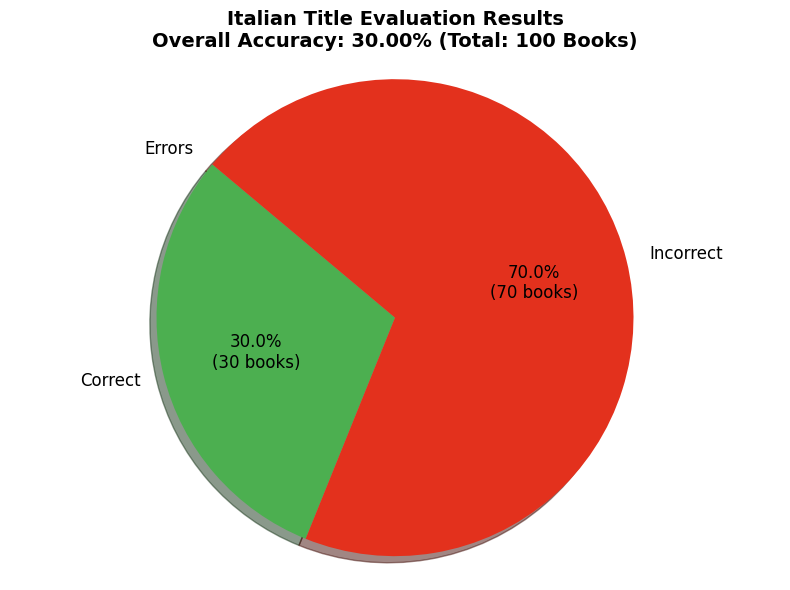

In [ ]:
plot_results(
    correct_predictions=correct_predictions_it_title,
    
    failed_parses=failed_parses_it_title,
    evaluation_set=italian_evaluation_set,
    title="Italian Title Evaluation Results",
)

## 7. Dutch books with Dutch titles

This section loads Dutch Gutenberg books, creates short text snippets, and builds a multiple-choice task using Dutch titles. Loading, evaluation, and plotting happen in one cell.

Loading Dutch Gutenberg books...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 Dutch books.
Created 100 Dutch multiple-choice questions.
Evaluated 10/100 | Running Accuracy: 40.0%
Evaluated 20/100 | Running Accuracy: 25.0%
Evaluated 30/100 | Running Accuracy: 20.0%
Evaluated 40/100 | Running Accuracy: 27.5%
Evaluated 50/100 | Running Accuracy: 28.0%
Evaluated 60/100 | Running Accuracy: 25.0%
Evaluated 70/100 | Running Accuracy: 24.3%
Evaluated 80/100 | Running Accuracy: 22.5%
Evaluated 90/100 | Running Accuracy: 21.1%
Evaluated 100/100 | Running Accuracy: 22.0%


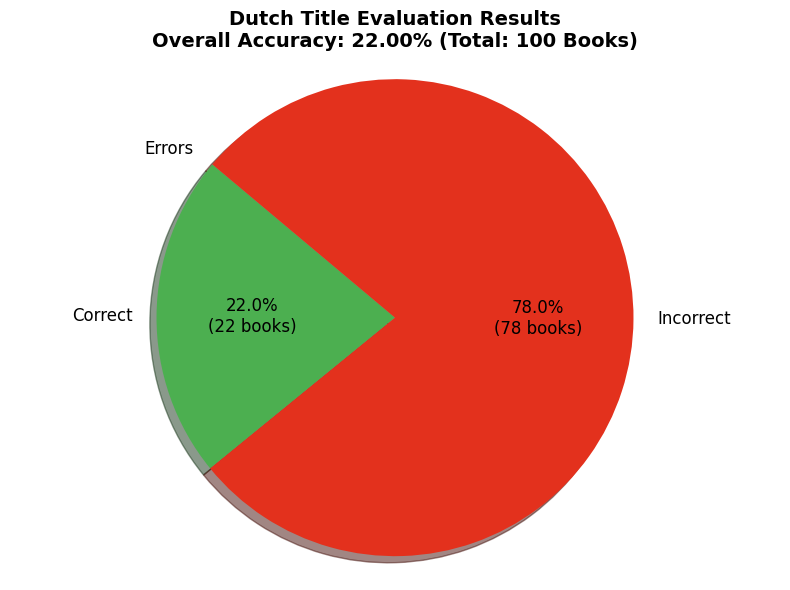

In [33]:
import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

print("Loading Dutch Gutenberg books...")
# Changed split to "nl" for the Netherlands / Dutch language
dataset_nl = load_dataset("manu/project_gutenberg", split="nl", streaming=True)

dutch_books = load_books_from_stream(
    dataset_nl,
    parse_title_fn=parse_metadata,
    target_count=NUM_TARGET_BOOKS,
    snippet_length=SNIPPET_LENGTH,
    skip_fn=None,
)

print(f"Loaded {len(dutch_books)} Dutch books.")

dutch_evaluation_set = build_multiple_choice_questions(
    dutch_books,
    correct_title_key="title",
    text_key="text",
)

print(f"Created {len(dutch_evaluation_set)} Dutch multiple-choice questions.")

# Load the model only if it has not already been loaded in this session
if "tokenizer" not in globals() or "model" not in globals():
    print(f"Loading model: {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype="auto",
        device_map="auto",
    )

correct_predictions_nl_title = 0
failed_parses_nl_title = 0

for i, item in enumerate(dutch_evaluation_set):
    prompt_choices = "\n".join([
        f"{chr(65 + idx)}) {choice}"
        for idx, choice in enumerate(item["choices"])
    ])

    # Translated system prompt into Dutch
    system_prompt = (
        "Je bent een behulpzame assistent. Lees de tekst van het gegeven Nederlandse boek "
        "en bepaal de juiste Nederlandse titel."
    )

    # Translated user prompt into Dutch
    user_prompt = (
        f"Hier is het begin van een Nederlands boek:\n\n{item['snippet']}\n\n"
        f"Uit welk Nederlands boek komt dit fragment? Kies de juiste optie:\n"
        f"{prompt_choices}\n\n"
        f"Antwoord ALLEEN met de bijbehorende letter (A, B, C of D)."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
        )

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses_nl_title += 1

    if predicted_letter == item["correct_letter"]:
        correct_predictions_nl_title += 1

    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions_nl_title / (i + 1)) * 100
        print(f"Evaluated {i+1}/{len(dutch_evaluation_set)} | Running Accuracy: {current_acc:.1f}%")

# Updated plotting details for Dutch results
plot_results(
    correct_predictions=correct_predictions_nl_title,
    failed_parses=failed_parses_nl_title,
    evaluation_set=dutch_evaluation_set,
    title="Dutch Title Evaluation Results",
)